In [1]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact

c:\Users\Raees\Desktop\stuff\NuOscProbExact


fatal: destination path 'NuOscProbExact' already exists and is not an empty directory.


In [2]:
import sys
sys.path.append(r"c:\Users\Raees\AppData\Local\Programs\Microsoft VS Code\NuOscProbExact\src")

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
from NuOscProbExact.src import  oscprob2nu, globaldefs, hamiltonians2nu
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import copy as cp

In [4]:
# Data from a NOvA report
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_nd = np.array([2, 26, 46, 60, 78, 94, 110, 124, 136, 142, 144, 139, 120, 80, 48, 26, 10, 4, 0.5])
counts_fd = np.array([0, 0.9, 0, 2, 1, 1, 1, 1, 3, 4, 5, 5, 8.2, 6, 4, 7.5, 1.9, 1, 0.9])

In [5]:
# Gaussian function
# fit to get peak, width and height
def gaus(x,p0,p1,p2):
    return p0 * math.e**((-0.5 * (x - p1)**2)/ p2**2)

# Function to generate counts from a Poisson distribution based on probabilities and Gaussian scaling    
def poisson_dist(probability, bin_centers, amplitude, mean, sigma):
    counts = np.random.poisson(probability * gaus(bin_centers,amplitude,mean,sigma)) 
    return counts

Fitted parameters for simulated ND events: Amplitude = 140.91490619526158, Mean = 1.749668477371812, Sigma = 0.507978228395975
Fitted parameters for simulated FD events: Amplitude = 6.779346901557666, Mean = 2.300245386238934, Sigma = 0.5580152784216936


Text(0.5, 0, 'Energy (GeV)')

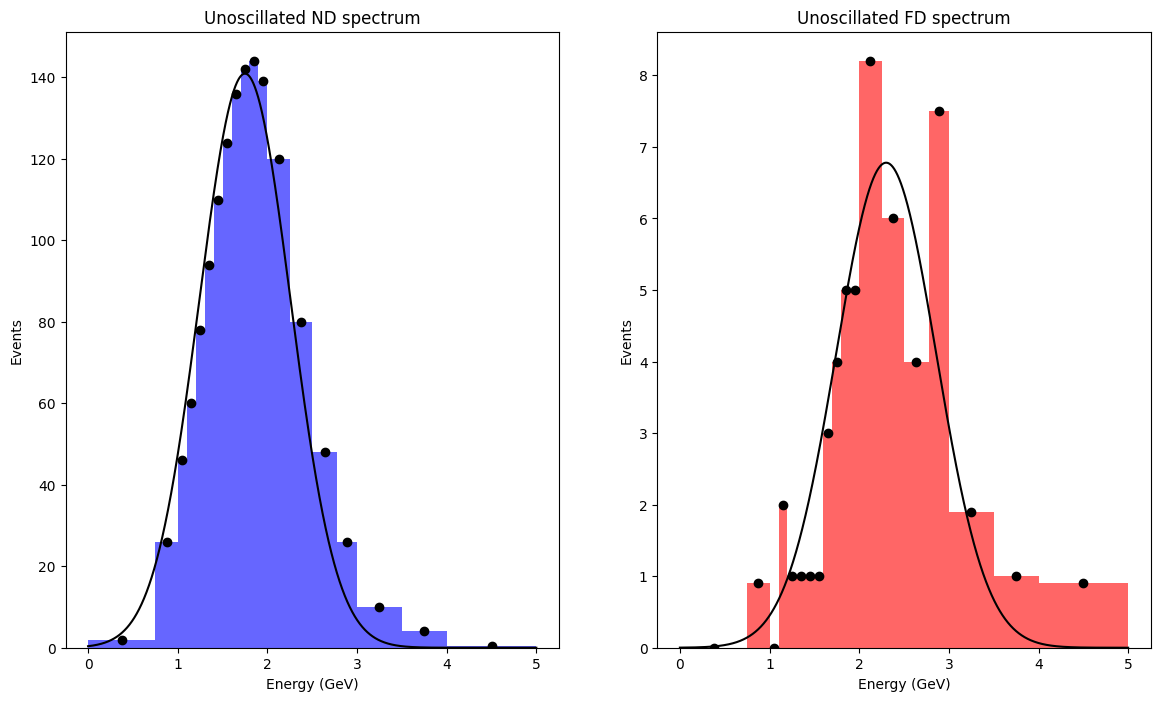

In [6]:
initial_guess_nd = [140,2,0.5]
initial_guess_fd = [8, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_edges[:-1], counts_nd, p0=initial_guess_nd)
popt_fd, _ = curve_fit(gaus, bin_edges[:-1], counts_fd, p0=initial_guess_fd)

print(f"Fitted parameters for simulated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")
print(f"Fitted parameters for simulated FD events: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")

fig, axs = plt.subplots(1, 2, figsize=(14, 8))

x = np.arange(0,5,0.001)

axs[0].hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.6, color='b')
axs[0].scatter(bin_centers, counts_nd, color='black')
axs[0].plot(x, gaus(x,*popt_nd), color='black')
axs[0].set_title("Unoscillated ND spectrum")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")

axs[1].hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.6, color='r')
axs[1].scatter(bin_centers, counts_fd, color='black')
axs[1].plot(x, gaus(x, *popt_fd), color='black')
axs[1].set_title("Unoscillated FD spectrum")
axs[1].set_ylabel("Events")
axs[1].set_xlabel("Energy (GeV)")


In [7]:
# parameters
length_nd = 1 # [km]
length_fd = 810 # [km]
energy = 1e9

In [8]:
def osc_probability_2nu(sector, case, length): 
    
    energy = 1e9 # Neutrino energy in eV

    # sector: '12' (solar mixing angle, mass squared diff), '23' (atmospheric mixing angle, mass squared diff)
    # case: vacuum, matter

    if sector == '12':
        mixing_angle = globaldefs.S12_NO_BF
        delta_mass_squared = globaldefs.D21_NO_BF
        label = ['Pee', 'Pem', 'Pme', 'Pmm']

    elif sector == '23':
        mixing_angle = globaldefs.S23_NO_BF
        delta_mass_squared = globaldefs.D31_NO_BF
        label = ['Pmm', 'Pmt', 'Ptm', 'Ptt']

    # Get the vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)

    # Determine Hamiltonian based on case
    if case == 'vacuum':
        h = np.multiply(1./energy, h_vacuum_energy_indep)
    elif case == 'matter':
        h = hamiltonians2nu.hamiltonian_2nu_matter(h_vacuum_energy_indep, energy, globaldefs.VCC_EARTH_CRUST)

    # Calculate probabilities
    probabilities = oscprob2nu.probabilities_2nu(h, length * globaldefs.CONV_KM_TO_INV_EV)

    # Print each label with its corresponding probability
    for lbl, prob in zip(label, probabilities):
        print(f'{lbl}: {prob:.5f}')

    return probabilities


In [9]:
prob_12_vc_nd = osc_probability_2nu(sector='12', case='vacuum', length=length_nd)
print('\n')
prob_23_vc_nd = osc_probability_2nu('23', 'vacuum', length_nd)

Pee: 1.00000
Pem: 0.00000
Pme: 0.00000
Pmm: 1.00000


Pmm: 0.99999
Pmt: 0.00001
Ptm: 0.00001
Ptt: 0.99999


Virtually no transitions from muon neutrinos to electron neutrinos, and from muon neutrinos to tau neutrinos at the near detector.

[  8  36  61  71  95 104 132 116 120 139 128 134 102  71  36  19   2   0
   0]
Fitted parameters for simulated ND events: Amplitude = 132.77457512814155, Mean = 1.6611326021518065, Sigma = 0.5360666395080387


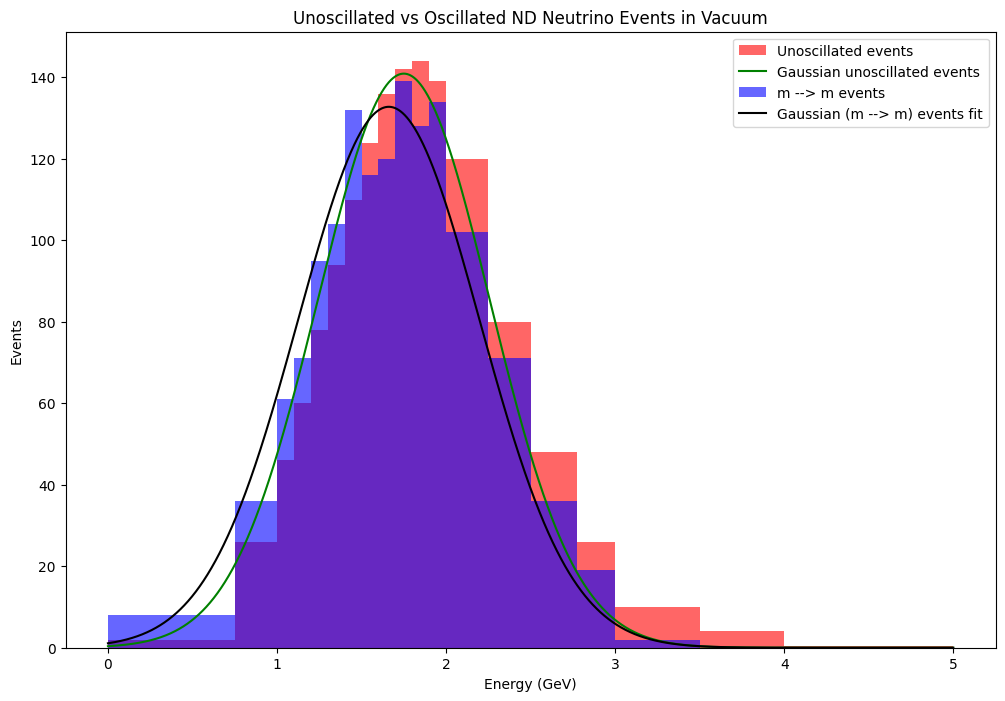

In [10]:
counts_Pmm_vc_nd = poisson_dist(prob_23_vc_nd[0], bin_centers, *popt_nd)
print(counts_Pmm_vc_nd)

popt_nd_vc, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmm_vc_nd, initial_guess_nd)
print(f"Fitted parameters for simulated ND events: Amplitude = {popt_nd_vc[0]}, Mean = {popt_nd_vc[1]}, Sigma = {popt_nd_vc[2]}")

plt.figure(figsize=(12,8))
plt.hist(bin_edges[:-1], bin_edges, weights=counts_nd, alpha=0.6, color='r', label='Unoscillated events')
plt.plot(x, gaus(x, *popt_nd), color='green', label='Gaussian unoscillated events')
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts_Pmm_vc_nd, density=False, alpha=0.6, color='b', label='m --> m events')
plt.plot(x, gaus(x, *popt_nd_vc), color='black',label='Gaussian (m --> m) events fit')
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.title('Unoscillated vs Oscillated ND Neutrino Events in Vacuum')
plt.legend()
plt.show()


In [11]:
prob_12_vc_fd = osc_probability_2nu(sector='12', case='vacuum', length=length_fd)
print('\n')
prob_23_vc_fd = osc_probability_2nu('23', 'vacuum', length_fd)
print('\n')
counts_Pme_vc_fd = poisson_dist(prob_12_vc_fd[2], bin_centers, *popt_fd)
print('Events m --> e:', counts_Pme_vc_fd)

counts_Pmm_vc_fd = poisson_dist(prob_23_vc_fd[0], bin_centers, *popt_fd)
print('Events m --> m:', counts_Pmm_vc_fd)

counts_Pmt_vc_fd = poisson_dist(prob_23_vc_fd[2], bin_centers, *popt_fd)
print('Events m --> t:', counts_Pmt_vc_fd)

Pee: 0.99509
Pem: 0.00491
Pme: 0.00491
Pmm: 0.99509


Pmm: 0.73380
Pmt: 0.26620
Ptm: 0.26620
Ptt: 0.73380


Events m --> e: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Events m --> m: [0 0 0 0 1 0 0 2 1 2 6 2 5 7 0 2 1 0 0]
Events m --> t: [0 0 1 1 0 2 0 1 2 3 2 1 1 1 2 1 0 0 0]


Fitted parameters for simulated FD events: Amplitude = 5.603720327452492, Mean = 2.0970262905567196, Sigma = 0.30528636730318126
Fitted parameters for simulated FD events: Amplitude = 1.699657192610083, Mean = 1.939928759595947, Sigma = 0.6499959753298843


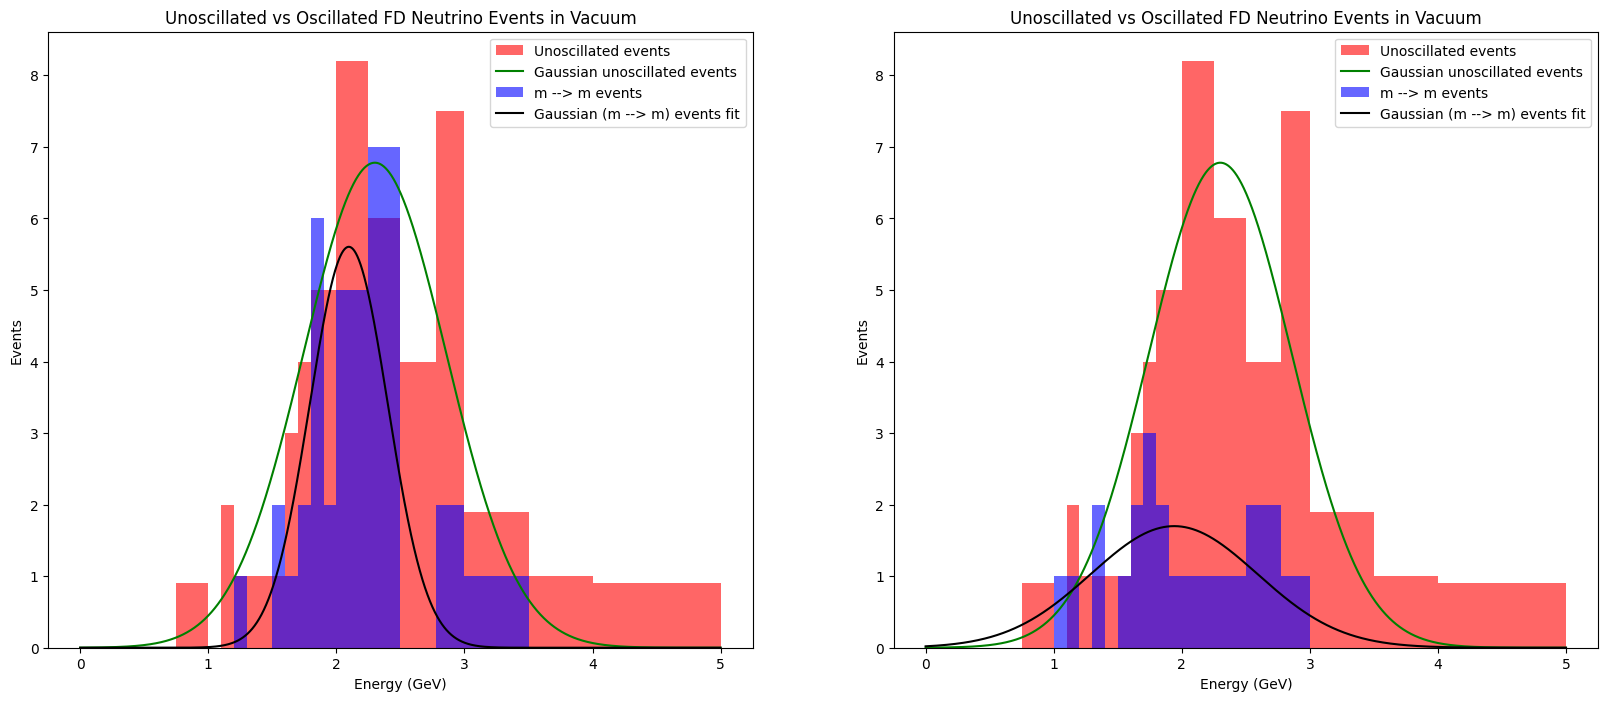

In [12]:
popt_fd_vc_mm, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmm_vc_fd, initial_guess_fd)
print(f"Fitted parameters for simulated FD events: Amplitude = {popt_fd_vc_mm[0]}, Mean = {popt_fd_vc_mm[1]}, Sigma = {popt_fd_vc_mm[2]}")

popt_fd_vc_mt, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmt_vc_fd, initial_guess_fd)
print(f"Fitted parameters for simulated FD events: Amplitude = {popt_fd_vc_mt[0]}, Mean = {popt_fd_vc_mt[1]}, Sigma = {popt_fd_vc_mt[2]}")

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

axs[0].hist(bin_edges[:-1], bin_edges, weights=counts_fd, alpha=0.6, color='r', label='Unoscillated events')
axs[0].plot(x, gaus(x, *popt_fd), color='green', label='Gaussian unoscillated events')
axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts_Pmm_vc_fd, density=False, alpha=0.6, color='b', label='m --> m events')
axs[0].plot(x, gaus(x, *popt_fd_vc_mm), color='black',label='Gaussian (m --> m) events fit')
axs[0].set_title('Unoscillated vs Oscillated FD Neutrino Events in Vacuum')
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")
axs[0].legend()


axs[1].hist(bin_edges[:-1], bin_edges, weights=counts_fd, alpha=0.6, color='r', label='Unoscillated events')
axs[1].plot(x, gaus(x, *popt_fd), color='green', label='Gaussian unoscillated events')
axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_Pmt_vc_fd, density=False, alpha=0.6, color='b', label='m --> m events')
axs[1].plot(x, gaus(x, *popt_fd_vc_mt), color='black',label='Gaussian (m --> m) events fit')
axs[1].set_title('Unoscillated vs Oscillated FD Neutrino Events in Vacuum')
axs[1].set_ylabel("Events")
axs[1].set_xlabel("Energy (GeV)")
axs[1].legend()

In [13]:
prob_12_matter_nd = osc_probability_2nu(sector='12', case='matter', length=length_nd)
print('\n')
prob_23_matter_nd = osc_probability_2nu('23', 'matter', length_nd)

Pee: 1.00000
Pem: 0.00000
Pme: 0.00000
Pmm: 1.00000


Pmm: 0.99999
Pmt: 0.00001
Ptm: 0.00001
Ptt: 0.99999


[  2  25  56  77 101 104 144 128 139 157 136 126  99  64  19  17   0   0
   0]
Fitted parameters for simulated ND events: Amplitude = 146.00461439042925, Mean = 1.6295369726720481, Sigma = 0.4652001345290802


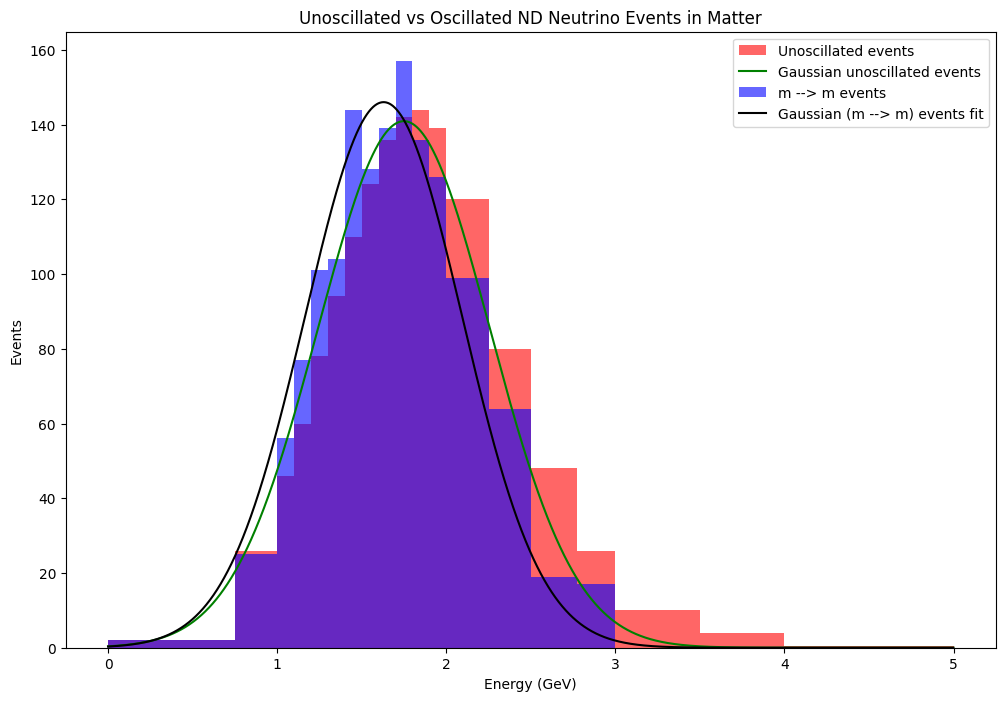

In [14]:
counts_Pmm_matter_nd = poisson_dist(prob_23_matter_nd[0], bin_centers, *popt_nd)
print(counts_Pmm_matter_nd)

popt_nd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmm_matter_nd, initial_guess_nd)
print(f"Fitted parameters for simulated ND events: Amplitude = {popt_nd_matter[0]}, Mean = {popt_nd_matter[1]}, Sigma = {popt_nd_matter[2]}")

plt.figure(figsize=(12,8))
plt.hist(bin_edges[:-1], bin_edges, weights=counts_nd, alpha=0.6, color='r', label='Unoscillated events')
plt.plot(x, gaus(x, *popt_nd), color='green', label='Gaussian unoscillated events')
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts_Pmm_matter_nd, density=False, alpha=0.6, color='b', label='m --> m events')
plt.plot(x, gaus(x, *popt_nd_matter), color='black',label='Gaussian (m --> m) events fit')
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.title('Unoscillated vs Oscillated ND Neutrino Events in Matter')
plt.legend()
plt.show()

In [15]:
prob_12_matter_fd = osc_probability_2nu(sector='12', case='matter', length=length_fd)
print('\n')
prob_23_matter_fd = osc_probability_2nu('23', 'matter', length_fd)
print('\n')
counts_Pme_matter_fd = poisson_dist(prob_12_matter_fd[2], bin_centers, *popt_fd)
print('Events m --> e:', counts_Pme_matter_fd)

counts_Pmm_matter_fd = poisson_dist(prob_23_matter_fd[0], bin_centers, *popt_fd)
print('Events m --> m:', counts_Pmm_matter_fd)

counts_Pmt_matter_fd = poisson_dist(prob_23_matter_fd[2], bin_centers, *popt_fd)
print('Events m --> t:', counts_Pmt_matter_fd)

Pee: 0.99520
Pem: 0.00480
Pme: 0.00480
Pmm: 0.99520


Pmm: 0.70291
Pmt: 0.29709
Ptm: 0.29709
Ptt: 0.70291


Events m --> e: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Events m --> m: [0 0 0 0 1 2 2 3 3 5 3 1 4 8 7 1 1 0 0]
Events m --> t: [0 0 1 1 0 0 0 1 1 2 1 3 2 4 1 1 0 0 0]


Fitted parameters for simulated FD events: Amplitude = 5.79699514734034, Mean = 2.2298028320737027, Sigma = 0.48591232415918156
Fitted parameters for simulated FD events: Amplitude = 3.1013890355238884, Mean = 2.143570770716262, Sigma = 0.3498514955836342


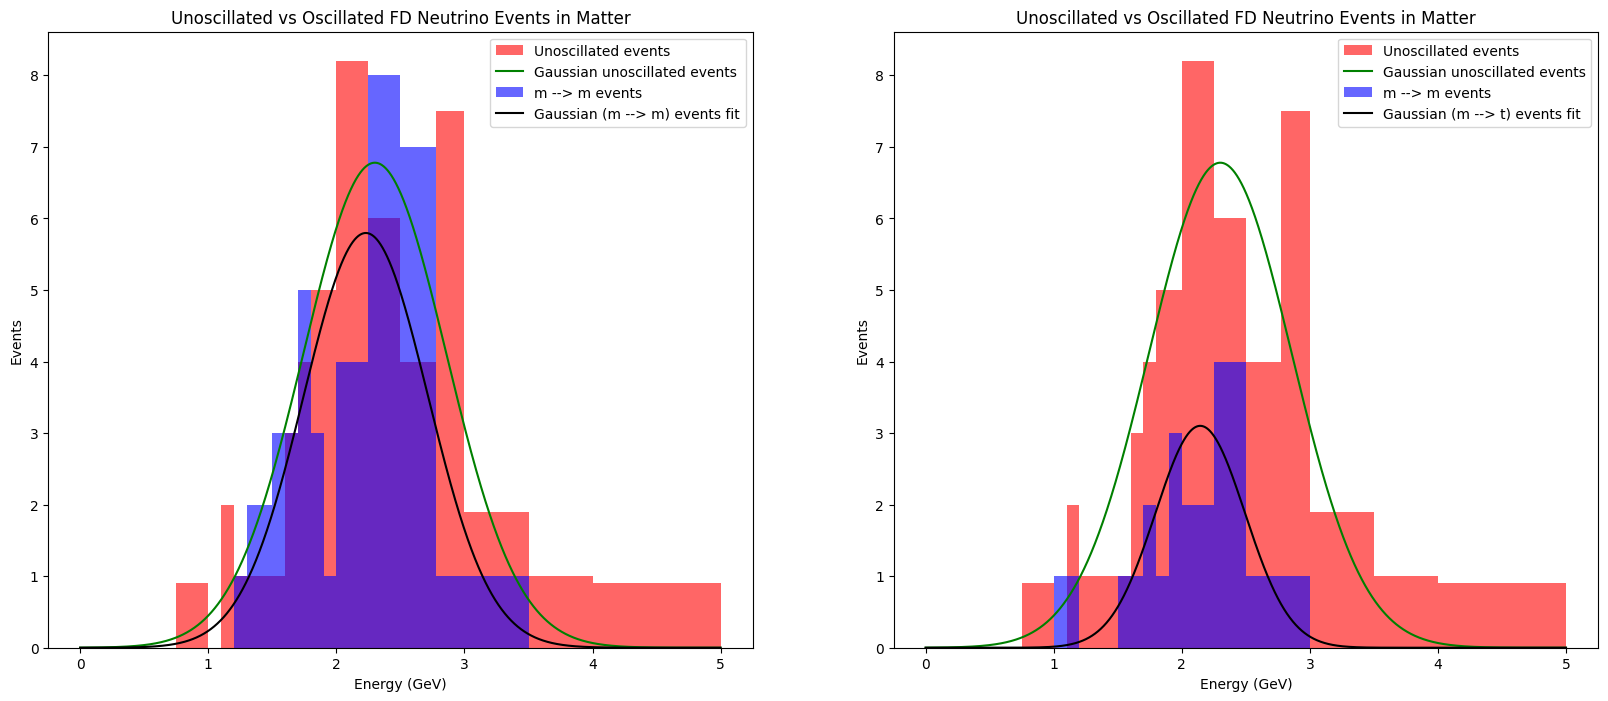

In [16]:
popt_fd_matter_mm, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmm_matter_fd, initial_guess_fd)
print(f"Fitted parameters for simulated FD events: Amplitude = {popt_fd_matter_mm[0]}, Mean = {popt_fd_matter_mm[1]}, Sigma = {popt_fd_matter_mm[2]}")

popt_fd_matter_mt, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmt_matter_fd, initial_guess_fd)
print(f"Fitted parameters for simulated FD events: Amplitude = {popt_fd_matter_mt[0]}, Mean = {popt_fd_matter_mt[1]}, Sigma = {popt_fd_matter_mt[2]}")

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

axs[0].hist(bin_edges[:-1], bin_edges, weights=counts_fd, alpha=0.6, color='r', label='Unoscillated events')
axs[0].plot(x, gaus(x, *popt_fd), color='green', label='Gaussian unoscillated events')
axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts_Pmm_matter_fd, density=False, alpha=0.6, color='b', label='m --> m events')
axs[0].plot(x, gaus(x, *popt_fd_matter_mm), color='black',label='Gaussian (m --> m) events fit')
axs[0].set_title('Unoscillated vs Oscillated FD Neutrino Events in Matter')
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")
axs[0].legend()


axs[1].hist(bin_edges[:-1], bin_edges, weights=counts_fd, alpha=0.6, color='r', label='Unoscillated events')
axs[1].plot(x, gaus(x, *popt_fd), color='green', label='Gaussian unoscillated events')
axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_Pmt_matter_fd, density=False, alpha=0.6, color='b', label='m --> m events')
axs[1].plot(x, gaus(x, *popt_fd_matter_mt), color='black',label='Gaussian (m --> t) events fit')
axs[1].set_title('Unoscillated vs Oscillated FD Neutrino Events in Matter')
axs[1].set_ylabel("Events")
axs[1].set_xlabel("Energy (GeV)")
axs[1].legend()

In [17]:
def plot_osc_2nu(sector, case, length, transition):

    probabilities = osc_probability_2nu(sector, case, length)

    if length == length_nd:
        popt = popt_nd
        weights1 = counts_nd
    elif length == length_fd:
        popt = popt_fd
        weights1 = counts_fd

    if transition == 'me':
        label1 = 'm --> e events'
        label2 = 'Gaussian (m --> e) events fit'
        index = 2
    elif transition == 'mt':
        index = 2
        label1 = 'm --> t events'
        label2 = 'Gaussian (m --> t) events fit'
    elif transition == 'mm':
        index = 0
        label1 = 'm --> m events'
        label2 = 'Gaussian (m --> m) events fit'

    counts = poisson_dist(probabilities[index], bin_centers, *popt)

    popt_osc, _ = curve_fit(gaus, bin_edges[:-1], counts)

    plt.figure(figsize=(12,8))
    plt.hist(bin_edges[:-1], bin_edges, weights=weights1, alpha=0.6, color='r', label='Unoscillated events')
    plt.plot(x, gaus(x, *popt), color='green', label='Gaussian unoscillated events')
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts, density=False, alpha=0.6, color='b', label=label1)
    plt.plot(x, gaus(x, *popt_osc), color='black',label=label2)
    plt.xlabel('Energy (GeV)')
    plt.ylabel('Events')
    plt.title('Unoscillated vs Oscillated Neutrino Events in ND')
    plt.legend()
    plt.show()

Pmm: 0.70291
Pmt: 0.29709
Ptm: 0.29709
Ptt: 0.70291


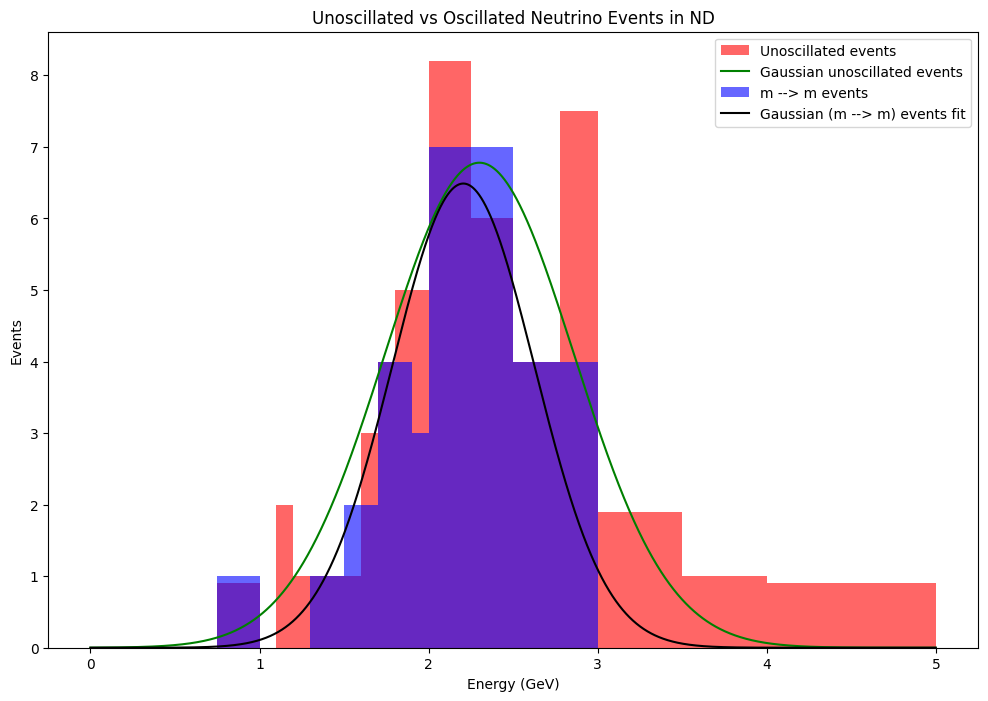

In [18]:
plot_osc_2nu(sector='23', case='matter', length=length_fd, transition='mm')